In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("results_nebulastream.csv")

df['system'] = 'NebulaStream'

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

df

,dataset,statistic_type,statistic_config,build_window_size_sec,bytesPerSecond,query_name,time,tuplesPerSecond,tuplesPerSecond_listener,latency_listener,...,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,enableLatency,statisticStoreType,issue,system,synopsis_type,query_variant
0,ClusterMonitoring,Reservoir,100,1,1.110462e+07,ClusterMonitoring_ReservoirBuild_100_1sec,137.578896,135551.727125,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
1,ClusterMonitoring,Reservoir,100,1,1.109925e+07,ClusterMonitoring_ReservoirBuild_100_1sec,137.645481,135486.155235,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
2,ClusterMonitoring,Reservoir,100,1,1.088335e+07,ClusterMonitoring_ReservoirBuild_100_1sec,140.376072,132850.682244,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
3,ClusterMonitoring,Reservoir,100,1,1.104767e+07,ClusterMonitoring_ReservoirBuild_100_1sec,138.288158,134856.499711,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
4,ClusterMonitoring,Reservoir,100,1,NaN,ClusterMonitoring_ReservoirBuild_100_1sec,NaN,NaN,NaN,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,crashed (SIGABRT),NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,7.402625e+07,ClusterMonitoring_CountMinBuild_10_10000_uint6...,20.638110,903622.325937,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
266,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,7.479601e+07,ClusterMonitoring_CountMinBuild_10_10000_uint6...,20.425715,913018.552920,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
267,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,6.686519e+07,ClusterMonitoring_CountMinBuild_10_10000_uint6...,22.848390,816208.790491,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
268,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,6.884342e+07,ClusterMonitoring_CountMinBuild_10_10000_uint6...,22.191838,840356.567774,-1.0,NaN,...,200000,HASH_JOIN,102400,8192,False,SUB_STORES,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec


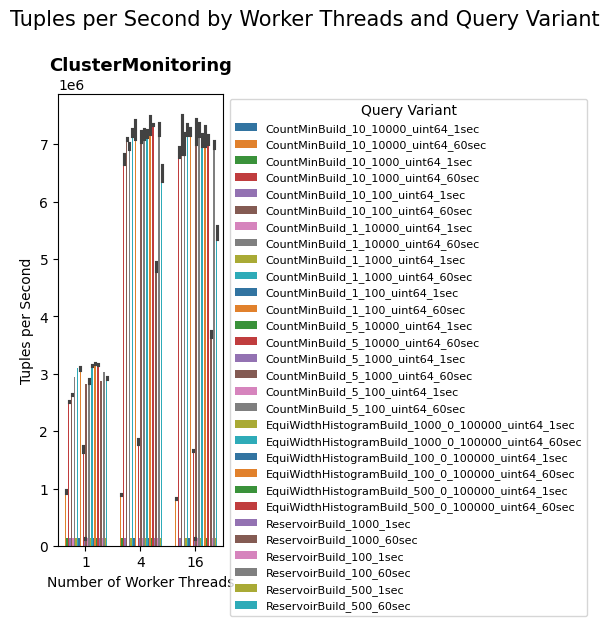

In [2]:
synopsis_types = df["synopsis_type"].unique()
n = len(synopsis_types)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

# Ensure axes is always iterable
if n == 1:
    axes = [axes]

for ax, synopsis in zip(axes, synopsis_types):
    subset = df[df["synopsis_type"] == synopsis]
    hue_order = sorted(subset["query_variant"].dropna().unique())
    palette = sns.color_palette("tab10", len(hue_order))

    sns.barplot(
        data=subset,
        x="numberOfWorkerThreads",
        y="tuplesPerSecond",
        hue="query_variant",
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        errorbar="sd",       # show standard deviation as error bars; use None to disable
    )

    ax.set_title(synopsis, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Worker Threads")
    ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
    ax.legend(title="Query Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Tuples per Second by Worker Threads and Query Variant", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(4), np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)'] at numberOfWorkerThreads=[np.int64(4), np.int64(16)] (7 failed rows)
  Excluding 2 ok (collateral) + 7 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['oom_killed', 'failed (exit code 11)'] at numberOfWorkerThreads=[np.int64(16)] (5 failed rows)
  Excluding 4 ok (collateral) + 5 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, stati

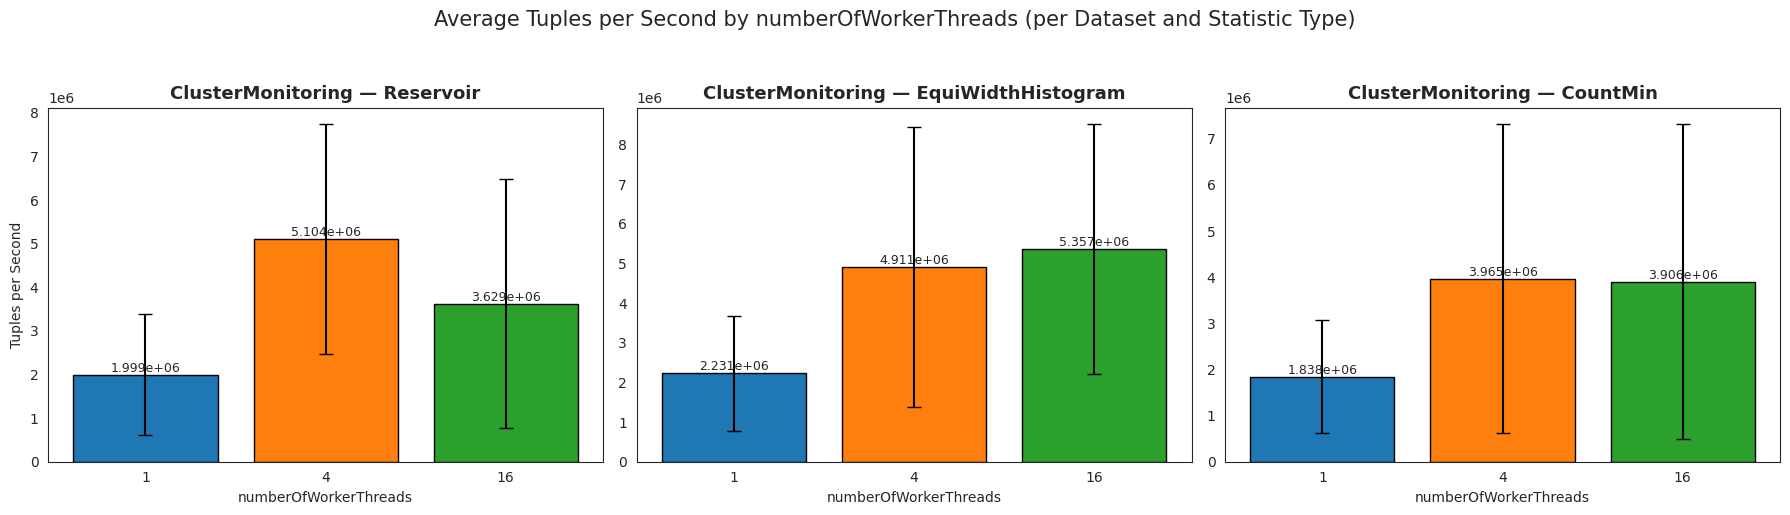

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(4), np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)'] at numberOfWorkerThreads=[np.int64(4), np.int64(16)] (7 failed rows)
  Excluding 2 ok (collateral) + 7 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['oom_killed', 'failed (exit code 11)'] at numberOfWorkerThreads=[np.int64(16)] (5 failed rows)
  Excluding 4 ok (collateral) + 5 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, stati

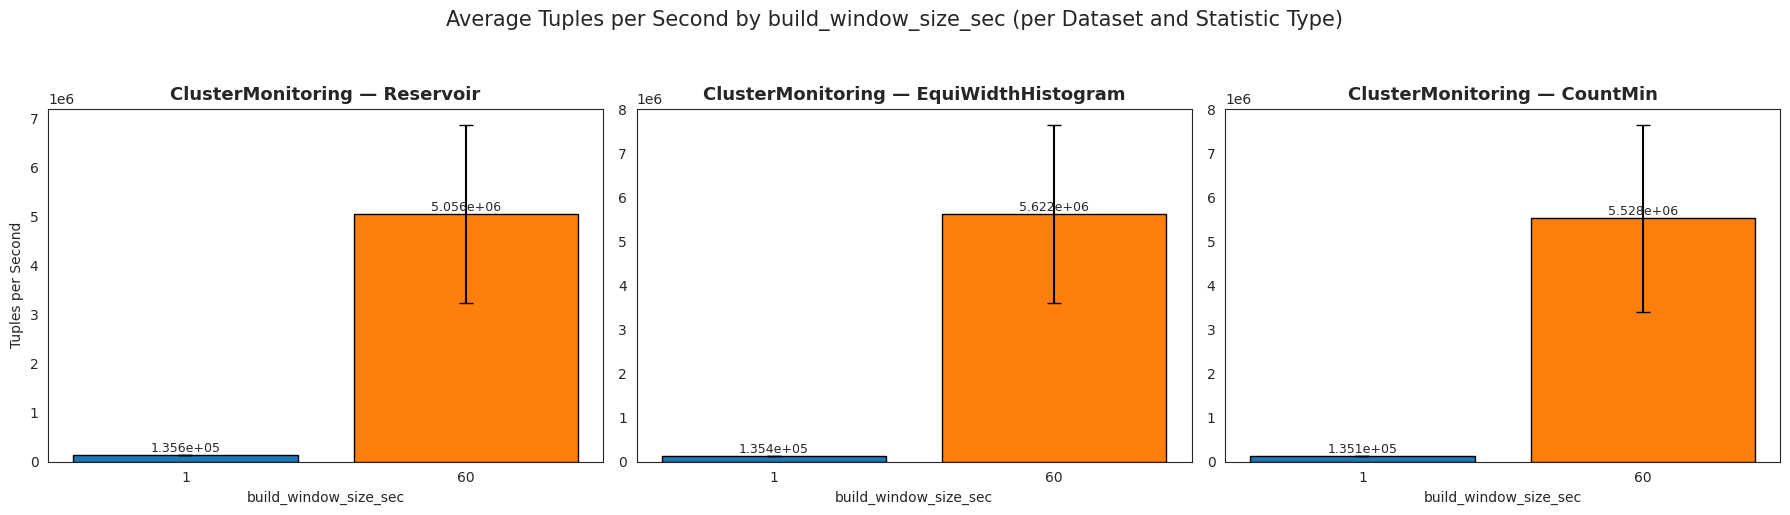

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), numberOfWorkerThreads=4, enableLatency=False
  Missing ok for build_window_size_sec=[np.int64(1)] (expected: [np.int64(1), np.int64(60)])
  Explicit failure(s): ['failed (exit code 11)'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Excluding 3 ok (collateral) + 3 failed rows

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), numberOfWorkerThreads=16, enableLatency=False
  Missing ok for build_window_size_sec=[np.int64(1)] (expected: [np.int64(1), np.int64(60)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Excluding 3 ok (collateral) + 3 failed rows

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), numberOfWorkerThreads=16, enableLaten

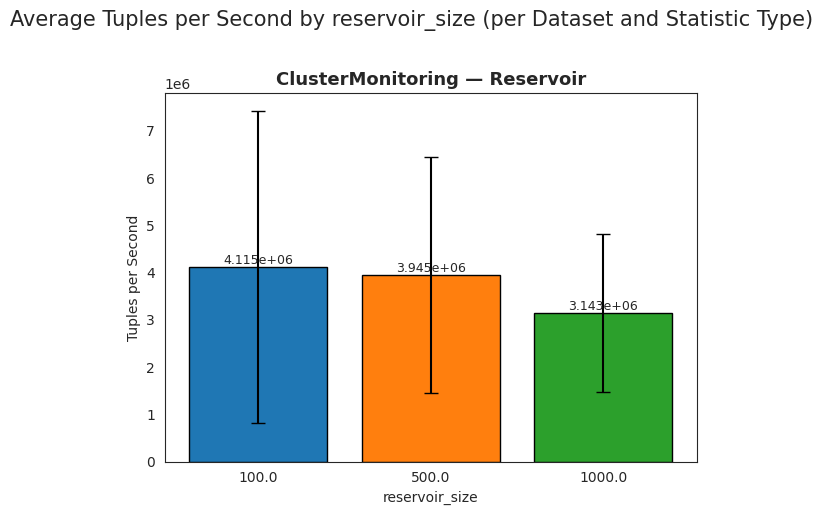

[reservoir_size] Config: dataset=ClusterMonitoring, statistic_type=Reservoir, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for reservoir_size=[np.float64(1000.0)] (expected: [np.float64(100.0), np.float64(500.0), np.float64(1000.0)])
  Explicit failure(s): ['crashed (SIGSEGV)'] at reservoir_size=[np.float64(1000.0)] (5 failed rows)
  Excluding 4 ok (collateral) + 5 failed rows

[reservoir_size] Total: excluded 9 rows (5 failed + 4 ok collateral + 0 missing combinations), 45 remaining
---
[reservoir_size/latency_listener] No latency data available, skipping plot.
[num_buckets] Config: dataset=ClusterMonitoring, statistic_type=EquiWidthHistogram, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for num_buckets=[np.float64(100.0)] (expected: [np.float64(100.0), np.float64(500.0), np.float64(1000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)'] at num_buckets=[np.float64(100.0)] (6 failed ro

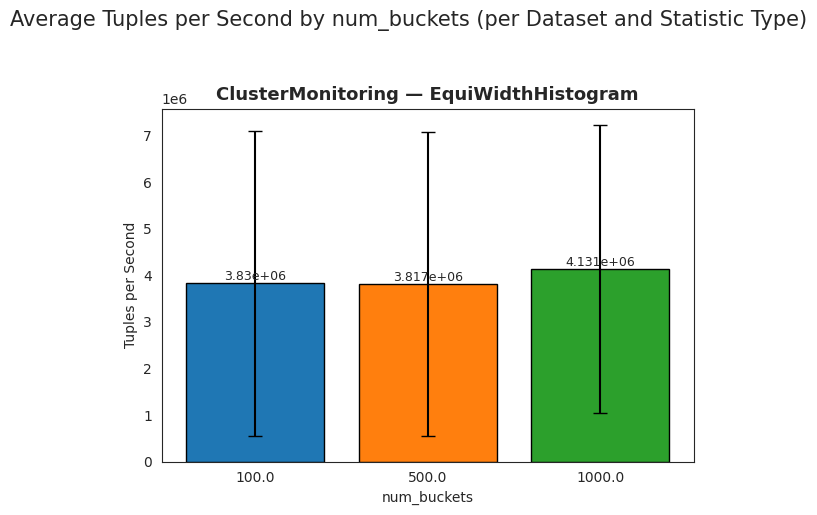

[num_buckets] Config: dataset=ClusterMonitoring, statistic_type=EquiWidthHistogram, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for num_buckets=[np.float64(100.0)] (expected: [np.float64(100.0), np.float64(500.0), np.float64(1000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)'] at num_buckets=[np.float64(100.0)] (6 failed rows)
  Excluding 3 ok (collateral) + 6 failed rows

[num_buckets] Total: excluded 9 rows (6 failed + 3 ok collateral + 0 missing combinations), 45 remaining
---
[num_buckets/latency_listener] No latency data available, skipping plot.
[cm_rows/tuplesPerSecond] All data has enableLatency=False, plotting single set of subplots.


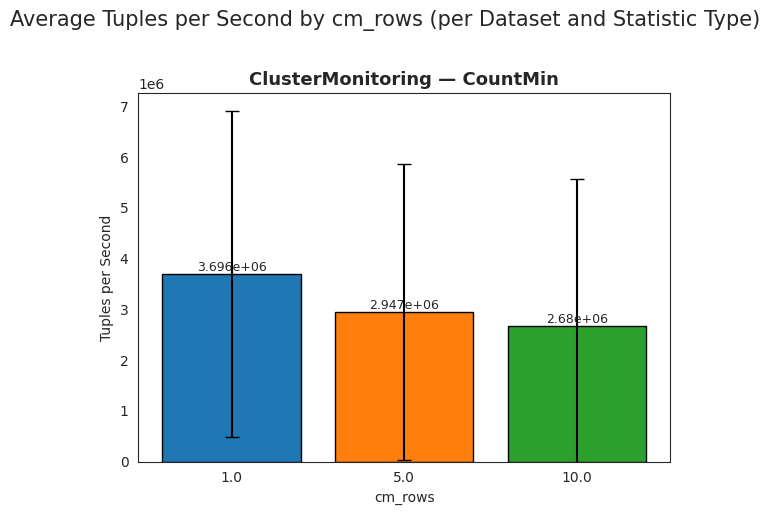

[cm_rows/latency_listener] No latency data available, skipping plot.
[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=4, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (11 failed rows)
  Excluding 16 ok (collateral) + 11 failed rows

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (14 failed rows)
  Excluding 13 ok (collateral) + 14 failed rows

[cm_cols] Total: excluded 54 rows (25 failed + 29 ok collateral +

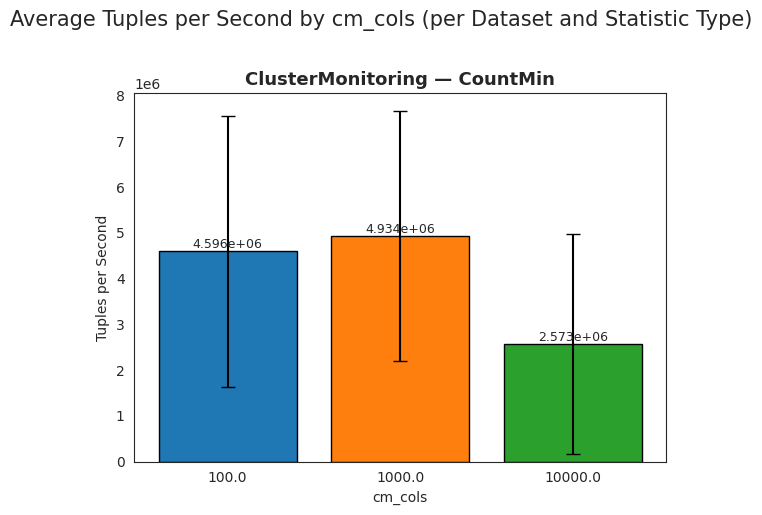

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=4, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (11 failed rows)
  Excluding 16 ok (collateral) + 11 failed rows

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['failed (exit code 11)', 'crashed (SIGSEGV)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (14 failed rows)
  Excluding 13 ok (collateral) + 14 failed rows

[cm_cols] Total: excluded 54 rows (25 failed + 29 ok collateral + 0 missing combinations), 108 remaining
---
[cm_cols/latency_listener

In [3]:
# Columns that together define a unique experiment configuration
CONFIG_COLS = ["dataset", "statistic_type", "statistic_config", "build_window_size_sec", "numberOfWorkerThreads", "enableLatency"]

def filter_failed_configs(df, iterate_param, config_cols=None):
    """
    Exclude all runs whose config (ignoring `iterate_param`) does not have an "ok"
    row for every value of `iterate_param` present in the dataset.

    This catches both explicit failures (issue != "ok") and missing rows caused by
    crashes that produced no CSV output at all — either way the config group is dropped
    so results are never skewed by an incomplete parameter sweep.

    When `iterate_param` is a derived column (e.g. reservoir_size, cm_rows) that is
    not itself in CONFIG_COLS but is encoded by statistic_config, statistic_config is
    also removed from key_cols so that configs with different statistic_config values
    are grouped together and can cross-check each other.
    """
    if config_cols is None:
        config_cols = CONFIG_COLS
    key_cols = [c for c in config_cols if c != iterate_param]
    # Derived params (reservoir_size, cm_rows, …) are encoded in statistic_config.
    # Keeping statistic_config in key_cols would put each derived value in its own
    # group, making cross-value coverage checks impossible.
    if iterate_param not in config_cols:
        key_cols = [c for c in key_cols if c != "statistic_config"]

    all_param_values = set(df[iterate_param].dropna().unique())

    # For each config group, check that every iterate_param value has >= 1 "ok" row
    def has_full_ok_coverage(group):
        ok_vals = set(group.loc[group["issue"] == "ok", iterate_param].dropna())
        return all_param_values.issubset(ok_vals)

    coverage = df.groupby(key_cols, group_keys=False).apply(has_full_ok_coverage)
    bad_index = coverage[~coverage].index

    if len(bad_index) == 0:
        return df

    # Reconstruct bad config keys as a DataFrame for merging
    if isinstance(bad_index, pd.MultiIndex):
        bad_keys = bad_index.to_frame(index=False)
    else:
        bad_keys = pd.DataFrame({key_cols[0]: bad_index})

    # Print details and accumulate summary counts
    total_failed = 0
    total_ok_collateral = 0
    total_missing_combos = 0

    for _, bkey in bad_keys.iterrows():
        mask = (df[key_cols] == bkey.values).all(axis=1)
        config_rows = df[mask]

        failed_rows = config_rows[config_rows["issue"] != "ok"]
        ok_rows = config_rows[config_rows["issue"] == "ok"]

        ok_vals = set(ok_rows[iterate_param].dropna())
        failed_vals = set(failed_rows[iterate_param].dropna())
        present_vals = set(config_rows[iterate_param].dropna())
        missing_vals = sorted(all_param_values - ok_vals)
        absent_vals = sorted(all_param_values - present_vals)   # no row at all
        explicit_fail_vals = sorted(failed_vals & (all_param_values - ok_vals))

        n_missing_combos = len(absent_vals)
        total_failed += len(failed_rows)
        total_ok_collateral += len(ok_rows)
        total_missing_combos += n_missing_combos

        config_str = ", ".join(f"{c}={bkey[c]}" for c in key_cols)
        print(f"[{iterate_param}] Config: {config_str}")
        print(f"  Missing ok for {iterate_param}={missing_vals} (expected: {sorted(all_param_values)})")
        if explicit_fail_vals:
            issues = failed_rows[failed_rows[iterate_param].isin(explicit_fail_vals)]["issue"].unique()
            print(f"  Explicit failure(s): {list(issues)} at {iterate_param}={explicit_fail_vals} ({len(failed_rows)} failed rows)")
        if absent_vals:
            print(f"  No rows at all for {iterate_param}={absent_vals} ({n_missing_combos} missing combination(s))")
        print(f"  Excluding {len(ok_rows)} ok (collateral) + {len(failed_rows)} failed rows")
        print()

    # Drop all rows belonging to incomplete config groups
    merged = df.merge(bad_keys, on=key_cols, how="left", indicator=True)
    clean = merged[merged["_merge"] == "left_only"].drop(columns="_merge")

    n_dropped = len(df) - len(clean)
    print(f"[{iterate_param}] Total: excluded {n_dropped} rows "
          f"({total_failed} failed + {total_ok_collateral} ok collateral + {total_missing_combos} missing combinations), "
          f"{len(clean)} remaining")
    print("---")

    return clean

_METRIC_LABEL = {
    "tuplesPerSecond":          "Tuples per Second",
    "tuplesPerSecond_listener": "Tuples per Second (listener)",
    "bytesPerSecond":           "Bytes per Second",
    "latency_listener":         "Avg Latency (s)",
}

def plot_avg_by(df, param, metric="tuplesPerSecond"):
    """Bar chart of avg `metric` per (dataset, statistic type), grouped by `param`.

    For latency_listener, rows with value -1 (no measurements) are excluded before
    aggregation. If no data remains after that filter the subplot is skipped.
    """
    df_clean = filter_failed_configs(df, param)

    if df_clean.empty:
        print(f"[{param}/{metric}] No data remaining after filtering, skipping plot.")
        return

    if metric == "latency_listener":
        if metric not in df_clean.columns:
            print(f"[{param}/latency_listener] Column not present in data, skipping plot.")
            return
        # Only include runs where the latency listener was actually enabled
        df_clean = df_clean[df_clean["enableLatency"] == True].copy()
        # Drop sentinel -1 values (listener enabled but produced no measurements)
        df_clean = df_clean[pd.to_numeric(df_clean[metric], errors="coerce").fillna(-1) != -1]
        if df_clean.empty:
            print(f"[{param}/latency_listener] No latency data available, skipping plot.")
            return

    ylabel = _METRIC_LABEL.get(metric, metric)
    suptitle = f"Average {ylabel} by {param} (per Dataset and Statistic Type)"

    datasets = sorted(df_clean["dataset"].unique())
    statistic_types = df_clean["statistic_type"].unique()
    latency_values = sorted(df_clean["enableLatency"].unique())
    multi_latency = len(latency_values) > 1

    if not multi_latency:
        print(f"[{param}/{metric}] All data has enableLatency={latency_values[0]}, plotting single set of subplots.")

    n_datasets = len(datasets)
    n_stats = len(statistic_types)

    for lat_val in latency_values:
        df_lat = df_clean[df_clean["enableLatency"] == lat_val]
        lat_suffix = f" (latency={'on' if lat_val else 'off'})" if multi_latency else ""

        with sns.axes_style("white"):
            fig, axes = plt.subplots(
                n_datasets, n_stats,
                figsize=(6 * n_stats, 5 * n_datasets),
                sharey=False,
                squeeze=False,
            )

            for row, dataset in enumerate(datasets):
                df_ds = df_lat[df_lat["dataset"] == dataset]
                for col, stat_type in enumerate(statistic_types):
                    ax = axes[row][col]
                    subset = df_ds[df_ds["statistic_type"] == stat_type].copy()
                    subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
                    subset = subset.dropna(subset=[metric])

                    if subset.empty:
                        ax.set_visible(False)
                        print(f"[{param}/{metric}] No data for {dataset} — {stat_type}{lat_suffix}, subplot hidden.")
                        continue

                    avg = subset.groupby(param)[metric].agg(["mean", "std"]).reset_index()
                    avg = avg.sort_values(param)

                    bars = ax.bar(
                        avg[param].astype(str),
                        avg["mean"],
                        yerr=avg["std"],
                        capsize=5,
                        color=sns.color_palette("tab10", len(avg)),
                        edgecolor="black",
                    )

                    ax.set_ylim(bottom=0)
                    ax.set_xlabel(param)
                    ax.set_ylabel(ylabel if col == 0 else "")
                    ax.set_title(f"{dataset} — {stat_type}{lat_suffix}", fontsize=13, fontweight="bold")

                    for bar in bars:
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.4g}",
                                ha="center", va="bottom", fontsize=9)

            fig.suptitle(suptitle + lat_suffix, fontsize=15, y=1.02)
            plt.tight_layout()
            plt.show()

# Parse statistic_config into dedicated columns per statistic type
# Reservoir: config is just the reservoir size
mask_res = df["statistic_type"] == "Reservoir"
df.loc[mask_res, "reservoir_size"] = df.loc[mask_res, "statistic_config"].astype(int)

# EquiWidthHistogram: "(num_buckets, min_value, max_value, counter_type)"
mask_hist = df["statistic_type"] == "EquiWidthHistogram"
df.loc[mask_hist, "num_buckets"] = (
    df.loc[mask_hist, "statistic_config"]
    .str.extract(r"\((\d+),")[0].astype(int)
)

# CountMin: "(rows, cols, counter_type)"
mask_cm = df["statistic_type"] == "CountMin"
cm_parts = df.loc[mask_cm, "statistic_config"].str.extract(r"\((\d+),\s*(\d+),")
df.loc[mask_cm, "cm_rows"] = cm_parts[0].astype(int)
df.loc[mask_cm, "cm_cols"] = cm_parts[1].astype(int)

# Common plots for all statistic types
plot_avg_by(df, "numberOfWorkerThreads")
plot_avg_by(df, "numberOfWorkerThreads", metric="latency_listener")

plot_avg_by(df, "build_window_size_sec")
plot_avg_by(df, "build_window_size_sec", metric="latency_listener")

# Per-statistic-type config plots
plot_avg_by(df[mask_res], "reservoir_size")
plot_avg_by(df[mask_res], "reservoir_size", metric="latency_listener")

plot_avg_by(df[mask_hist], "num_buckets")
plot_avg_by(df[mask_hist], "num_buckets", metric="latency_listener")

plot_avg_by(df[mask_cm], "cm_rows")
plot_avg_by(df[mask_cm], "cm_rows", metric="latency_listener")

plot_avg_by(df[mask_cm], "cm_cols")
plot_avg_by(df[mask_cm], "cm_cols", metric="latency_listener")

In [4]:
# ── Probe Analysis ──────────────────────────────────────────────────────────

PROBE_CONFIG_COLS = [
    "dataset", "statistic_type", "statistic_config", "build_window_size_sec",
    "num_statistic_ids", "build_windows_per_probe_window", "num_probe_tuples",
    "numberOfWorkerThreads", "enableLatency",
]

_PROBE_METRIC_LABEL = {
    "probe_throughput_listener": "Probe Tuples per Second (listener)",
    "probe_latency_listener":    "Avg Probe Latency (s)",
}

df_probe = pd.read_csv("results_statistic_probe.csv")

# Parse statistic_config into dedicated columns (same logic as build)
mask_res_p  = df_probe["statistic_type"] == "Reservoir"
mask_hist_p = df_probe["statistic_type"] == "EquiWidthHistogram"
mask_cm_p   = df_probe["statistic_type"] == "CountMin"

df_probe.loc[mask_res_p, "reservoir_size"] = df_probe.loc[mask_res_p, "statistic_config"].astype(int)
df_probe.loc[mask_hist_p, "num_buckets"] = (
    df_probe.loc[mask_hist_p, "statistic_config"].str.extract(r"\((\d+),")[0].astype(int)
)
cm_parts_p = df_probe.loc[mask_cm_p, "statistic_config"].str.extract(r"\((\d+),\s*(\d+),")
df_probe.loc[mask_cm_p, "cm_rows"] = cm_parts_p[0].astype(int)
df_probe.loc[mask_cm_p, "cm_cols"] = cm_parts_p[1].astype(int)

df_probe


def plot_probe_avg_by(df, param, metric="probe_throughput_listener"):
    """Bar chart for probe measurements, analogous to plot_avg_by for build.

    Row dimension: (dataset, num_probe_repetitions) — treated like separate datasets.
    Column dimension: (statistic_type, enableLatency) — same logic as build plots.

    For probe_latency_listener, only enableLatency=True rows are used; if the
    column is absent (early datasets) the plot is skipped with a message.
    """
    df_clean = filter_failed_configs(df, param, config_cols=PROBE_CONFIG_COLS)

    if df_clean.empty:
        print(f"[{param}/{metric}] No data remaining after filtering, skipping plot.")
        return

    # Drop sentinel -1 values (invalid measurements) for any metric
    if metric not in df_clean.columns:
        print(f"[{param}/{metric}] Column not present in data, skipping plot.")
        return
    df_clean = df_clean[pd.to_numeric(df_clean[metric], errors="coerce").fillna(-1) != -1].copy()
    if df_clean.empty:
        print(f"[{param}/{metric}] All values are -1 (invalid), skipping plot.")
        return

    ylabel = _PROBE_METRIC_LABEL.get(metric, metric)
    suptitle = f"Average {ylabel} by {param} (per Dataset, Repetitions and Statistic Type)"

    if metric == "probe_latency_listener":
        if metric not in df_clean.columns:
            print(f"[{param}/probe_latency_listener] Column not present in data, skipping plot.")
            return
        df_clean = df_clean[df_clean["enableLatency"] == True].copy()
        df_clean = df_clean[pd.to_numeric(df_clean[metric], errors="coerce").fillna(-1) != -1]
        if df_clean.empty:
            print(f"[{param}/probe_latency_listener] No latency data available, skipping plot.")
            return

    datasets        = sorted(df_clean["dataset"].unique())
    rep_values      = sorted(df_clean["num_probe_repetitions"].unique())
    statistic_types = df_clean["statistic_type"].unique()
    latency_values  = sorted(df_clean["enableLatency"].unique())
    multi_latency   = len(latency_values) > 1

    if not multi_latency:
        print(f"[{param}/{metric}] All data has enableLatency={latency_values[0]}, plotting single set of subplots.")

    row_groups = [(ds, reps) for ds in datasets for reps in rep_values]
    n_rows = len(row_groups)
    n_stats = len(statistic_types)

    for lat_val in latency_values:
        df_lat = df_clean[df_clean["enableLatency"] == lat_val]
        lat_suffix = f" (latency={'on' if lat_val else 'off'})" if multi_latency else ""

        with sns.axes_style("white"):
            fig, axes = plt.subplots(
                n_rows, n_stats,
                figsize=(6 * n_stats, 5 * n_rows),
                sharey=False,
                squeeze=False,
            )

            for row, (dataset, n_reps) in enumerate(row_groups):
                df_row = df_lat[
                    (df_lat["dataset"] == dataset) &
                    (df_lat["num_probe_repetitions"] == n_reps)
                ]
                for col, stat_type in enumerate(statistic_types):
                    ax = axes[row][col]
                    subset = df_row[df_row["statistic_type"] == stat_type].copy()
                    subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
                    subset = subset.dropna(subset=[metric])

                    if subset.empty:
                        ax.set_visible(False)
                        print(f"[{param}/{metric}] No data for {dataset} reps={n_reps} — {stat_type}{lat_suffix}, subplot hidden.")
                        continue

                    avg = subset.groupby(param)[metric].agg(["mean", "std"]).reset_index()
                    avg = avg.sort_values(param)

                    bars = ax.bar(
                        avg[param].astype(str),
                        avg["mean"],
                        yerr=avg["std"],
                        capsize=5,
                        color=sns.color_palette("tab10", len(avg)),
                        edgecolor="black",
                    )

                    ax.set_ylim(bottom=0)
                    ax.set_xlabel(param)
                    ax.set_ylabel(ylabel if col == 0 else "")
                    ax.set_title(f"{stat_type}{lat_suffix}", fontsize=13, fontweight="bold")
                    if col == 0:
                        ax.annotate(
                            f"{dataset}\nreps={n_reps}",
                            xy=(0, 0.5), xycoords="axes fraction",
                            xytext=(-70, 0), textcoords="offset points",
                            ha="center", va="center",
                            fontsize=11, fontweight="bold", rotation=90,
                        )

                    for bar in bars:
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.4g}",
                                ha="center", va="bottom", fontsize=9)

            fig.suptitle(suptitle + lat_suffix, fontsize=15, y=1.02)
            plt.tight_layout(rect=[0.08, 0, 1, 0.97])
            plt.show()


# Common plots
plot_probe_avg_by(df_probe, "numberOfWorkerThreads")
plot_probe_avg_by(df_probe, "numberOfWorkerThreads", metric="probe_latency_listener")

plot_probe_avg_by(df_probe, "build_window_size_sec")
plot_probe_avg_by(df_probe, "build_window_size_sec", metric="probe_latency_listener")

plot_probe_avg_by(df_probe, "num_statistic_ids")
plot_probe_avg_by(df_probe, "num_statistic_ids", metric="probe_latency_listener")

plot_probe_avg_by(df_probe, "build_windows_per_probe_window")
plot_probe_avg_by(df_probe, "build_windows_per_probe_window", metric="probe_latency_listener")

plot_probe_avg_by(df_probe, "num_probe_tuples")
plot_probe_avg_by(df_probe, "num_probe_tuples", metric="probe_latency_listener")

# Per-statistic-type config plots
plot_probe_avg_by(df_probe[mask_res_p], "reservoir_size")
plot_probe_avg_by(df_probe[mask_res_p], "reservoir_size", metric="probe_latency_listener")

plot_probe_avg_by(df_probe[mask_hist_p], "num_buckets")
plot_probe_avg_by(df_probe[mask_hist_p], "num_buckets", metric="probe_latency_listener")

plot_probe_avg_by(df_probe[mask_cm_p], "cm_rows")
plot_probe_avg_by(df_probe[mask_cm_p], "cm_rows", metric="probe_latency_listener")

plot_probe_avg_by(df_probe[mask_cm_p], "cm_cols")
plot_probe_avg_by(df_probe[mask_cm_p], "cm_cols", metric="probe_latency_listener")

FileNotFoundError: [Errno 2] No such file or directory: 'results_statistic_probe.csv'